# File Loading & structural Audit

In [1]:
import pandas as pd
import numpy as np

rfp_dt = pd.read_csv("Resale flat prices.csv")
rfp_dt

print("====Dataset Shape====")
print(f"Overall Number of Row: {rfp_dt.shape[0]}")
print(f"Overall Number of Collumns: {rfp_dt.shape[1]}")

print("====Data Types====")
print(rfp_dt.dtypes)

/Users/prithvisadanand/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


====Dataset Shape====
Overall Number of Row: 233374
Overall Number of Collumns: 11
====Data Types====
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object


The dataset consist of 233,374 rows and 11 columns, with a merge of object, float64, and int64 data types for fields involving resale price, floor area, and lease details. Main phrase engage reviewing for missing values and validating the accountability of privotal numeric columns.

# Quality & Missing Data Audit

In [2]:
rfp_dt.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [3]:
# numeric data summary

rfp_dt[['floor_area_sqm', 'resale_price']].describe().round(2)

,floor_area_sqm,resale_price
count,233374.00,233374.00
mean,96.69,530975.37
std,24.02,190148.39
min,31.00,140000.00
25%,81.00,390000.00
50%,93.00,500000.00
75%,112.00,638000.00
max,366.70,1728000.00


- There is no missing values and the dataset is clean. 
- ***Numeric Data Summary*** shows amazing business output where smallest flat is ***31 sqm*** and the largest is ***366.7 sqm***. The cheapest flats sold for ***140,000***, simultaneously the expensive surpases ***1,728,000*** (a million-dollar HDB, which is a major announcemnet in Singapore at present!).

# Feature Engineering

In [4]:
# calculate price per meter
rfp_dt['price_per_sqm'] = rfp_dt['resale_price'] / rfp_dt['floor_area_sqm']

# extract year and month from month column
rfp_dt['transaction_year'] = rfp_dt['month'].str.split("-").str[0].astype(int)
rfp_dt['transaction_month'] = rfp_dt['month'].str.split("-").str[1].astype(int)

print("=== New Review Colomn === ")
print(rfp_dt[['month','transaction_year','transaction_month','price_per_sqm']].head(3))

print("==== Newly Updated Market Values ====")
print(rfp_dt[['price_per_sqm']].describe().round(2))

=== New Review Colomn === 
     month  transaction_year  transaction_month  price_per_sqm
0  2017-01              2017                  1    5272.727273
1  2017-01              2017                  1    3731.343284
2  2017-01              2017                  1    3910.447761
==== Newly Updated Market Values ====
       price_per_sqm
count      233374.00
mean         5552.35
std          1655.27
min          2089.55
25%          4382.70
50%          5272.73
75%          6307.69
max         16148.94


***Based on the metrics***:

- The average price of public housing in Singapore marks at ***5,552.35*** per square meter. 
- The maximum value is an extensive at 16,148.94 per square meter (High-probability prime, top-floor unit in a central location!).

# Geographic Analysis

In [5]:
city_analysis = rfp_dt.groupby('town').agg(avg_price_per_sqm=('price_per_sqm', 'mean'),
                                           total_transactions=('resale_price', 'count')
                                          ).round(2).sort_values(by='avg_price_per_sqm', ascending=False)

print("=== TOP 10 MOST EXPENSIVE TOWNS IN SINGAPORE ===")
print(city_analysis.head(10))

print("\n=== TOP 5 CHEAPEST TOWNS IN SINGAPORE ===")
print(city_analysis.tail(5))

=== TOP 10 MOST EXPENSIVE TOWNS IN SINGAPORE ===
                 avg_price_per_sqm  total_transactions
town                                                  
CENTRAL AREA               8292.31                1817
QUEENSTOWN                 7673.17                6357
BUKIT MERAH                7301.76                8912
BUKIT TIMAH                7071.56                 569
KALLANG/WHAMPOA            6816.68                7112
BISHAN                     6635.83                4070
TOA PAYOH                  6522.18                7646
CLEMENTI                   6427.63                5184
MARINE PARADE              6414.07                1422
GEYLANG                    6048.23                5809

=== TOP 5 CHEAPEST TOWNS IN SINGAPORE ===
               avg_price_per_sqm  total_transactions
town                                                
YISHUN                   4958.82               15849
JURONG EAST              4927.73                4747
JURONG WEST              4651.82    

In [17]:
#markdown

# Structural Analysis

In [6]:
# Group by flat_type to analyze average size and price metrics
flat_type_analysis = rfp_dt.groupby('flat_type').agg(
    avg_price=('resale_price', 'mean'),
    avg_size_sqm=('floor_area_sqm', 'mean'),
    avg_price_per_sqm=('price_per_sqm', 'mean'),
    total_sales=('resale_price', 'count')
).round(2).sort_values(by='avg_price_per_sqm', ascending=False)

print("=== FLAT TYPE MARKET METRICS ===")
print(flat_type_analysis)

=== FLAT TYPE MARKET METRICS ===
                  avg_price  avg_size_sqm  avg_price_per_sqm  total_sales
flat_type                                                                
1 ROOM            214838.30         31.00            6930.27           87
2 ROOM            305226.83         45.71            6703.25         4847
4 ROOM            536035.54         95.02            5677.00        99075
3 ROOM            376569.77         68.14            5539.59        55580
5 ROOM            631184.56        117.72            5381.06        57089
MULTI-GENERATION  862625.91        161.28            5362.94           86
EXECUTIVE         738854.32        144.83            5098.24        16610


In [19]:
# markdown

# Market Momentum

In [7]:
# Group by year to see the market trajectory
yearly_trend = rfp_dt.groupby('transaction_year').agg(
    avg_resale_price=('resale_price', 'mean'),
    avg_price_per_sqm=('price_per_sqm', 'mean'),
    sales_volume=('resale_price', 'count')
).round(2)

# Calculate Year-over-Year price percentage change
yearly_trend['price_growth_pct'] = yearly_trend['avg_price_per_sqm'].pct_change() * 100
yearly_trend['price_growth_pct'] = yearly_trend['price_growth_pct'].round(2)

print("=== SINGAPORE HDB YEAR-BY-YEAR MARKET MOMENTUM ===")
print(yearly_trend)

=== SINGAPORE HDB YEAR-BY-YEAR MARKET MOMENTUM ===
                  avg_resale_price  avg_price_per_sqm  sales_volume  \
transaction_year                                                      
2017                     443888.52            4578.88         20509   
2018                     441282.06            4509.67         21561   
2019                     432137.91            4476.80         22186   
2020                     452279.38            4669.83         23333   
2021                     511381.24            5248.68         29087   
2022                     549714.33            5723.79         26720   
2023                     571806.01            6071.26         25754   
2024                     612596.94            6493.36         27832   
2025                     652521.60            6953.80         25085   
2026                     658857.26            7006.57         11307   

                  price_growth_pct  
transaction_year                    
2017                  

# Visualization

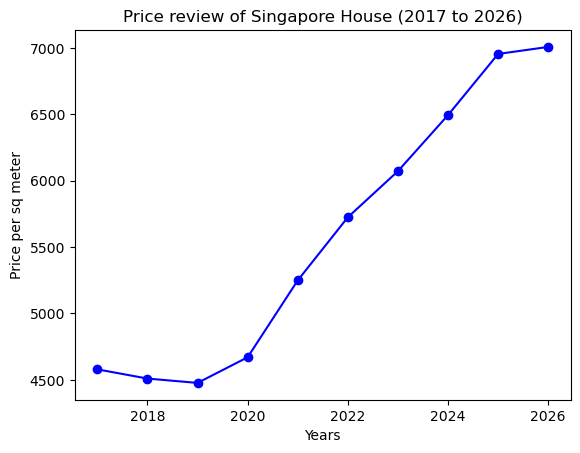

In [8]:
import matplotlib.pyplot as plt

# Choose the columns that is used to plot from yearly trend data
trans_years = yearly_trend.index
trans_prices = yearly_trend['avg_price_per_sqm']


# Plot a simple line chart with dots
plt.plot(trans_years, trans_prices, marker = 'o', color = 'blue')

# add a titles and labels 
plt.title("Price review of Singapore House (2017 to 2026)")
plt.xlabel("Years")
plt.ylabel("Price per sq meter")

# diplay the chart
plt.show()

In [25]:
rfp_dt.to_csv('newly_updated_clean_singapore_hdb.csv', index=False)
print("Saved successfully!")

Saved successfully!


This graphs displayes that housing prices faced down fall between 2017 and 2019, nad then the shot raised high after the year 2020.